TRANSFORMER: LA RIVOLUZIONE DELL'ARCHITETTURA SENZA RICORRENZE.

E' il momento in cui l'intelligenza artificiale ha smesso di leggere ed ha iniziato a guardare.

Immagina di voler capire una fotografia scansionandola un pixel alla volta è lento, faticoso e si perde la vista d'insieme
Le reti neurali viste finora facevano essattamente questo con il testo.
Con i transformer l'intera frase viene percepita in un unico istante, ho quindi una visione panoramica.

Cosa ci teneva bloccati nel passato?
Per anni abbiamo creduto che per capire il linguaggio servisse la ricorsività. Ma le RNN hanno un difetto, sono incredibilmente lente. Immagina una catena di montaggio dove ogni operaio deve aspettare che quello precedente finisca il suo pezzo.
Le GPU sono nate per fare miliardi di calcoli in parallelo, stavano li ad aspettare il token successivo.
Nel 2017 un team di google ha dimostrato che potevamo ottenere risultati incredibili eliminando i loop e usando solo l'attenzione.

Vantaggi strutturali di questa scelta
Perchè abbandonare le RNN
il primo motivo è la parallelizzazione massiva, poichè non dobbiamo aspettare l'elaborazione dello step precedente, possiamo dare in pasto alla rete l'intero testo in un colpo solo. Inoltre c'è il concetto di path lenght costante, nella LSTM l'informazione doveva viaggiare attraversi decine di celle, rischiando di svanire. Nei trasformer ogni parole è a distanza 1 da tutte le altre. non c'è più il problema del gradiente che scompare a causa delle moltiplicazioni ripeture. E' un architettura che non soffre di amnesia, indipendentemente dalla lunghezza del testo.

Dal Sequenziale al Parallelo
L'intera frase viene trasformata in una matrice di dati. Questo permette di sfruttare appieno la potenza di calcolo tensoriale delle GPU moderne. Immagina di guardare un'intera pagina di un libro non riga per riga, ma scattendo un'intera foto ad alta risoluzione.
Questo permette una scalabità mostruosa, possiamo addestrare modelli con miliardi di parametri poichè non siamo più legati ai tempi del passato.
Grazie a questas tecnica, ogni posizione da 0 a n ha n vettore PE differente che non interferisce col significato semantico della parola (scalabilità)
Il modello può capire che la relazione tra la posizione 2 e 5 è la stesso che intercorre tra la 10 e 13 (indipendenza temporale)
Tuttavia c'è una sfida, il modello diventa temporaneamente cieco, per lui una frase è un set disordinato di parole come un sacco di scarabei in una scatola. Senza accorgimenti extra perde il senso della sintassi.
Ma questo è un prezzo che paghiamo volentieri per la velocità

Complessità Computazionale
Confronto tra RNN e Self-Attention
Mentre nelle RNN il tempo di calcolo per layer dipende linearmente dalla lunghezza dellafase sequenza /n, nel Transformer le operazioni sono dominate dal prodotto tra matrici. Le GPU adorano i prodotti tra matrici, quindi anche se facciamo più calcoli li facciamo tutti nello stesso istante.
Questo rende il Transformer estremamente veloce per sequenze di lunghezza moderato, dove d è la dimensione del modello.

Come il modello capisce il contesto senza usare i loop
Self-Attention e Multi-Head
Il motore Query, Key, Value
Il cuore del Transformer è la Self-Attention, un meccanismo che permette a ogni parola di 'votare' l'importanza di tutte le altre parole nella frase.
Immagina ogni parola della frase come un elettore che osserva tutte le altre parole e decide quanto ognuna di esse, sia importante per definire il proprio significato.
Attraverso Query, Key e Value, la rete impare a focalizzarsi dinamicamente sui contesti rilevanti, superando la staticità dei word embeddings classici.
Per far funzonare tutto questo dobbiamo interpretare 3 ruoli diversi

La Triade QKV
I tre ruoli di ogni token
Usiamo un'anologia, la ricerca su youtube
* Query (Q): rappresenta la domanda corrente: "Cosa sto cercando in questo momento per capire meglio me stessa?" E' quello che viene scritto nella barra di ricerca.
* Key (K): rappresenta l'offerta. "Quale tipo di informazione o contesto posso offrire alle altre parole?" E' io titolo o tag di tutto ciò che è disponibile
- Value (V): l'informazione reale che viene estratta una volta torvato l'allineamento tra Query e Key. E' il contenuto del video stesso
- Scaled Dot-Production: il calcolo matematico che determina quanto pesare ogni Value in base alla similarità Q-K
Il prodotto scalare scalato determina quanto la domanda di una parola sia soddisfatta dall'offerta delle altre.

Multi-Head Attention
-Proiezione Multiple: invece di un solo meccanismo di attenzione, ne usiamo diversi (heads) in parallelo. 
- Diversità Semantica: una testa potrebbe focalizzarsi sul soggetto del verbo, mentre un'altra sugli aggeettivi che descrivono il nome
- Concatenazione: Gli output di tutte le 'teste' vengono concatenati e proiettati nuovamente per formare l'output finale del layer.

Ogni Attention può imparare relazioni diverse (es. una per la sintassi, una per la semantica).
Immagina un gruppo di esperti che analizzano la stessa frase, una testa (head) potrebbe essere uno specialista di grammatica e prestare attenzione sulla relazione tra soggetto e verso, un'altra testa (head) potrebbe essere un esperto di semantica e guardare gli aggettivi, una terza potrebbe cercare i riferimenti temporali. Tutte queste teste lavorano in parallelo e catturano sfumature diversi che una singola attenzione ignorerebbe.
Alla fine uniamo il tutto in un unico vettore di output, è la forza della diversità applicata ai dati.

Abbiamo quindi la velocità ed abbiamo il contesto, ma abbiamo perso l'ordine. come lo recuperiamo?

Positional Encoding
Restituire l'ordine alle sequenze.
Senza un segnale di posizione "il cane morde l'uomo" e "l'uomo morde il cane" sarebbero identiche.
Il Positional Encoding è la soluzione: aggiungiamo un vettore unico a ogni embedding per indicare la sua poszione assoluta relativa.
Serve per fargli capire dove si trova ogni parola all'interno di una frase, e non solo capiosce la posizione ma anche la distanza assoluta tra le varie parole. Il modello può capire che la relazione tra la posizione 2 e 5 è la stessa che intercorre tra 10 e 13.

L'idea rivoluzionaria è questa:
Invece di usare RNN, LSTM, GRU per far passare l'informazione da un token all sucessivo, il Transformer usa soprattutto il meccanismo di Attention per mettere direttamente in relazione i token tra loro.
Nel modello ricorrente avevaom:
token 1 -> token 2 -> token 3 -> token 4  --- l'informazione passa passo dopo passo
Con i Transformer invece
token 1 -- token 2
        -- token 3
        -- token 4
token 2 -- token 1
        -- token 3
        -- token 4
Ogni token può quindi guardare direttamente gli altri token rilevanti della sequenza.
Questo è il concetto di Self-Attention

Prendiamo la frase: "li cliente che ha telefonato ieri ha confermato l'ordine"
quando il modello elabora "ha confermato" può dare molta attenzione a "cliente", anche se tra le due parti ci sono diversi token
Cun una RNN/LSTM l'informazione deve attraversare tutto
Con Self-Attentio, concettualmente
clinete -----> ha confermato
la relazione può essere modellata direttamente
Ed è questa una delle ragioni per cui i Transformer riescono molto bene a modellare dipendenze anche lontane.

La struttura originaria del Transformer, introdotta nel lavoro "Attention Is All You Need" è ancora una struttura Seq2Seq
intput -> encoder -> rappresentazione dell'input -> decoder -> output
La differenza rispetto al vecchio Seq2Seq è cosa c'è dentro Encoder e Decoder.
Prima:
Encoder: LSTM/GRU
Decoder:LSTM/GRU
Nel Transformer
Encoder -> Self Attention -> Feed Forward.
Decoder -> Mask Self-Attention - Cross-Attention - Fedd Forward

Pre-processing: Caricamento e padding del dataset IMDB...

Inizio addestramento: Il modello impara la relazione parole-sentiment...
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 0.5813 - sentiment_output_accuracy: 0.6575 - val_loss: 0.3448 - val_sentiment_output_accuracy: 0.8482
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 0.2963 - sentiment_output_accuracy: 0.8755 - val_loss: 0.4296 - val_sentiment_output_accuracy: 0.8068
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - loss: 0.2176 - sentiment_output_accuracy: 0.9128 - val_loss: 0.3607 - val_sentiment_output_accuracy: 0.8450
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 0.1466 - sentiment_output_accuracy: 0.9470 - val_loss: 0.4120 - val_sentiment_output_accuracy: 0.8384
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - loss: 0.0936 - sentiment_output_accuracy: 0.9662 - val_loss: 0.5672 - val_sentiment_output_accuracy: 0.8219
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms

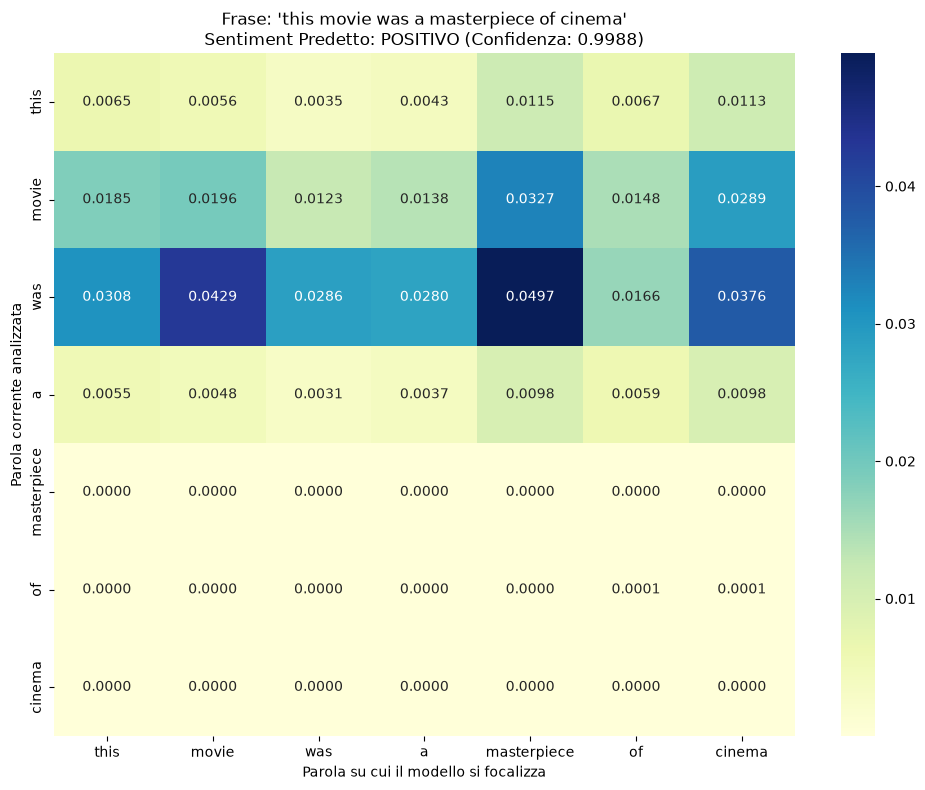

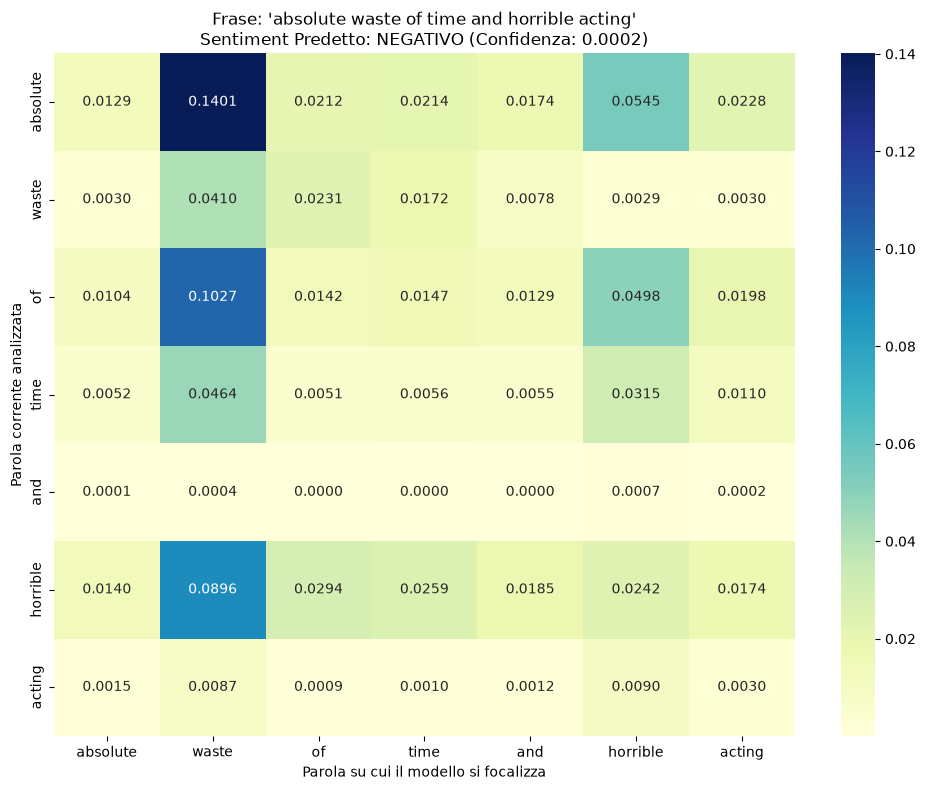

In [1]:
import os

# Configurazione del Backend: Utilizziamo PyTorch come motore di calcolo per Keras 3.
# Questo permette di sfruttare le performance di Torch mantenendo la semplicità dell'API Keras.
os.environ["KERAS_BACKEND"] = "torch"

import keras
from keras import layers, ops
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================================================
# 1. SINUSOIDAL POSITIONAL ENCODING LAYER
# =========================================================================================
# I Transformer non hanno una struttura sequenziale intrinseca. La formula sinusoidale
# (Seno e Coseno) permette al modello di conoscere la posizione relativa e assoluta
# dei token senza dover "imparare" dei pesi aggiuntivi per le posizioni.
# =========================================================================================
class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        # Token Embedding: Converte gli ID delle parole in vettori densi.
        self.token_embeddings = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        
        self.sequence_length = sequence_length
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        
        # Pre-calcoliamo la matrice delle posizioni usando la formula:
        # PE(pos, 2i) = sin(pos / 10000^(2i/d))
        # PE(pos, 2i+1) = cos(pos / 10000^(2i/d))
        self.positional_encoding = self._get_sinusoidal_encoding(sequence_length, embed_dim)

    def _get_sinusoidal_encoding(self, length, dim):
        # Generiamo le posizioni [0, 1, ..., length-1]
        pos = np.arange(length)[:, np.newaxis]
        # Generiamo gli indici delle dimensioni [0, 1, ..., dim-1]
        i = np.arange(dim)[np.newaxis, :]
        
        # Calcoliamo i "tassi d'angolo" (angle rates)
        # 2 * (i // 2) serve per avere lo stesso coefficiente sia per il seno che per il coseno della coppia
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(dim))
        angle_rads = pos * angle_rates

        # Applichiamo il seno agli indici pari e il coseno agli indici dispari
        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        # Convertiamo in un tensore costante (non addestrabile)
        pos_encoding = angle_rads[np.newaxis, ...]
        return ops.cast(pos_encoding, dtype="float32")

    def call(self, inputs):
        # inputs shape: [Batch, Sequence_length]
        length = ops.shape(inputs)[-1]
        
        # Trasformiamo le parole in vettori
        embedded_tokens = self.token_embeddings(inputs)
        
        # Preleviamo la porzione di codifica posizionale necessaria
        # (se la frase è più corta della lunghezza massima)
        positions = self.positional_encoding[:, :length, :]
        
        # SOMMA: Uniamo l'informazione semantica (parola) con quella geometrica (seno/coseno).
        return embedded_tokens + positions

# =========================================================================================
# 2. COSTRUZIONE DEL MODELLO TRANSFORMER
# =========================================================================================
# Questa funzione definisce l'architettura. La particolarità è che restituisce due output:
# il sentiment (previsione) e la matrice di attenzione (per la spiegabilità).
# =========================================================================================
def build_transformer_model(vocab_size, maxlen, embed_dim, num_heads):
    # INPUT: Sequenza di interi (token ID) di lunghezza fissa 'maxlen'
    inputs = layers.Input(shape=(maxlen,), name="input_layer")
    
    # STEP 1: Embedding + Posizione
    # Trasformiamo gli ID in vettori che "sanno" dove si trovano nella frase.
    x = PositionalEmbedding(maxlen, vocab_size, embed_dim)(inputs)
    
    # STEP 2: Multi-Head Attention (Il "Cuore" del Transformer)
    # Permette al modello di guardare diverse parti della frase simultaneamente.
    # 'return_attention_scores=True' è fondamentale per poter visualizzare la heatmap dopo.
    attention_output, attention_scores = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=embed_dim, name="attention_layer"
    )(x, x, return_attention_scores=True)
    
    # STEP 3: Estrazione della Matrice di Attenzione
    # Creiamo un "ponte" tramite un layer Activation lineare per marchiare l'output degli score.
    attention_matrix = layers.Activation("linear", name="attention_matrix")(attention_scores)
    
    # STEP 4: Riduzione e Classificazione
    # GlobalAveragePooling1D: Comprime la sequenza mediando i vettori delle parole.
    # Da [Sequence_length, Embed_dim] passiamo a un singolo vettore [Embed_dim].
    x = layers.GlobalAveragePooling1D()(attention_output)
    
    # LayerNormalization & Dropout: Regolarizzano prevenendo l'overfitting e stabilizzando i pesi.
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    # OUTPUT FINALE: Sigmoide per classificazione binaria (0=Negativo, 1=Positivo).
    sentiment_output = layers.Dense(1, activation="sigmoid", name="sentiment_output")(x)

    # Il modello ha un ingresso e DUE uscite: previsione e pesi dell'attenzione.
    model = keras.Model(inputs=inputs, outputs=[sentiment_output, attention_matrix])
    return model

# =========================================================================================
# 3. COORDINATORE DELL'ESPERIMENTO
# =========================================================================================
def run_experiment():
    # Iperparametri
    vocab_size = 10000 # Prendiamo solo le 10.000 parole più comuni
    maxlen = 100      # Tronchiamo/Padderemo ogni recensione a 100 parole
    embed_dim = 64    # Dimensione dello spazio vettoriale delle parole
    num_heads = 4     # Numero di "prospettive" diverse nell'attenzione
    
    print("Pre-processing: Caricamento e padding del dataset IMDB...")
    (x_train, y_train), (x_val, y_val) = keras.datasets.imdb.load_data(num_words=vocab_size)
    
    # Padding: Uniformiamo le frasi a lunghezza 100 inserendo zeri dove necessario.
    x_train = keras.utils.pad_sequences(x_train, maxlen=maxlen)
    x_val = keras.utils.pad_sequences(x_val, maxlen=maxlen)
    
    # Istanziamo il modello tramite la funzione definita sopra
    model = build_transformer_model(vocab_size, maxlen, embed_dim, num_heads)
    
    # Compilazione: specifichiamo che la perdita (loss) va calcolata solo sul sentiment.
    # La matrice di attenzione non necessita di perdita (loss=None).
    model.compile(
        optimizer="adam",
        loss=["binary_crossentropy", None],
        metrics={"sentiment_output": "accuracy"}
    )

    print("\nInizio addestramento: Il modello impara la relazione parole-sentiment...")
    model.fit(x_train, y_train, validation_data=(x_val, y_val), batch_size=64, epochs=10)

    # Frasi di test scritte da noi per vedere se il modello ha "capito"
    custom_phrases = [
        "this movie was a masterpiece of cinema",
        "absolute waste of time and horrible acting",
    ]
    
    # Passiamo alla fase di visualizzazione
    visualize_attention(model, custom_phrases, maxlen)

# =========================================================================================
# 4. VISUALIZZAZIONE DEI PESI DELL'ATTENZIONE
# =========================================================================================
def visualize_attention(model, sentences, maxlen):
    # Scarichiamo il dizionario per convertire parole in ID come fatto nel dataset IMDB
    word_index = keras.datasets.imdb.get_word_index()
    
    for text in sentences:
        # 1. Tokenizzazione: Spezziamo la frase in parole e convertiamo in ID
        tokens = text.lower().split()
        # Nota: L'indice IMDB è shiftato di 3 (0=padding, 1=start, 2=oov)
        seq = [word_index.get(w, -3) + 3 for w in tokens]
        
        # 2. Padding a 100 per renderlo compatibile con l'input del modello
        padded = keras.utils.pad_sequences([seq], maxlen=maxlen)
        
        # 3. Predizione: Otteniamo sia il Sentiment che la Matrice di Attenzione
        pred, attn = model.predict(padded, verbose=0)
        
        # Estraiamo i pesi della PRIMA testa di attenzione (index 0)
        # La matrice ha forma [Batch, Heads, Seq_len, Seq_len]
        weights = ops.convert_to_numpy(attn)[0, 0] 
        
        # 4. Ritaglio: Poiché la frase è lunga 100 ma noi abbiamo scritto poche parole,
        # prendiamo solo l'angolo in basso a destra della matrice (le ultime 'n' parole).
        n = len(tokens)
        relevant_weights = weights[-n:, -n:]
        
        # 5. Plotting con Seaborn per creare la Heatmap
        plt.figure(figsize=(10, 8))
        sns.heatmap(relevant_weights, annot=True, fmt=".4f", cmap="YlGnBu",
                    xticklabels=tokens, yticklabels=tokens)
        
        # Mostriamo il sentiment predetto sopra il grafico
        sentiment_label = 'POSITIVO' if pred[0][0] > 0.5 else 'NEGATIVO'
        plt.title(f"Frase: '{text}'\nSentiment Predetto: {sentiment_label} (Confidenza: {pred[0][0]:.4f})")
        plt.xlabel("Parola su cui il modello si focalizza")
        plt.ylabel("Parola corrente analizzata")
        plt.tight_layout()
        plt.show()

# Punto di ingresso dello script
if __name__ == "__main__":
    run_experiment()